In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/stats/pokemon_stats.csv")

In [3]:
df.head()

,id,name,height,weight,types,abilities,hp,attack,defense,special-attack,special-defense,speed
0,1,bulbasaur,7,69,"grass,poison","overgrow,chlorophyll",45,49,49,65,65,45
1,2,ivysaur,10,130,"grass,poison","overgrow,chlorophyll",60,62,63,80,80,60
2,3,venusaur,20,1000,"grass,poison","overgrow,chlorophyll",80,82,83,100,100,80
3,4,charmander,6,85,fire,"blaze,solar-power",39,52,43,60,50,65
4,5,charmeleon,11,190,fire,"blaze,solar-power",58,64,58,80,65,80


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1025 non-null   int64 
 1   name             1025 non-null   object
 2   height           1025 non-null   int64 
 3   weight           1025 non-null   int64 
 4   types            1025 non-null   object
 5   abilities        1025 non-null   object
 6   hp               1025 non-null   int64 
 7   attack           1025 non-null   int64 
 8   defense          1025 non-null   int64 
 9   special-attack   1025 non-null   int64 
 10  special-defense  1025 non-null   int64 
 11  speed            1025 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 96.2+ KB


In [10]:
df.describe()

,id,height,weight,hp,attack,defense,special-attack,special-defense,speed
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,513.000000,12.116098,669.865366,70.184390,77.521951,72.507317,70.080976,70.205854,67.186341
std,296.036315,12.481673,1212.731138,26.631054,29.782541,29.286972,29.658378,26.639329,28.717227
min,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,257.000000,5.000000,85.000000,50.000000,55.000000,50.000000,47.000000,50.000000,45.000000
50%,513.000000,10.000000,280.000000,68.000000,75.000000,70.000000,65.000000,67.000000,65.000000
75%,769.000000,15.000000,700.000000,85.000000,100.000000,90.000000,90.000000,86.000000,88.000000
max,1025.000000,200.000000,9999.000000,255.000000,181.000000,230.000000,173.000000,230.000000,200.000000


In [6]:
numerical_df = df.select_dtypes(include='number')


numerical_columns = numerical_df.columns.tolist()


In [8]:
numerical_columns.remove('id')

In [9]:
numerical_columns

['height',
 'weight',
 'hp',
 'attack',
 'defense',
 'special-attack',
 'special-defense',
 'speed']

In [4]:
def plot_hist_and_box(df, column):
    """
    Plots a histogram and a boxplot for the specified column from the DataFrame.
    The histogram and boxplot are shown as subplots in a single figure.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})
    # Histogram
    sns.histplot(df[column], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {column}')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('')
    plt.tight_layout()
    plt.show()

height Hist and Box plot


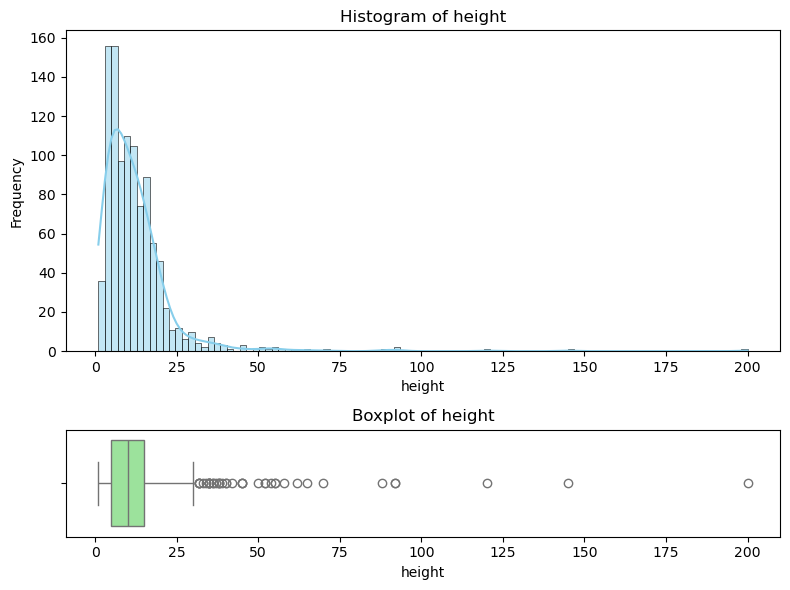

weight Hist and Box plot


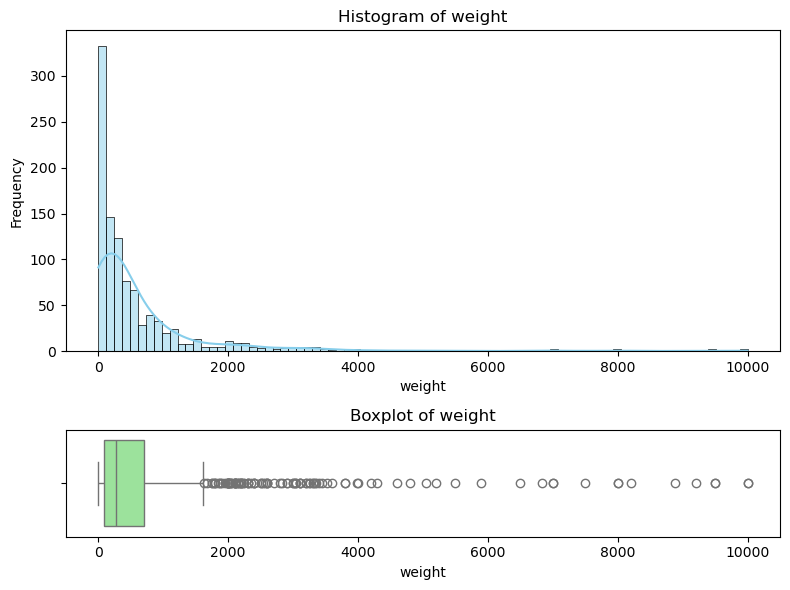

hp Hist and Box plot


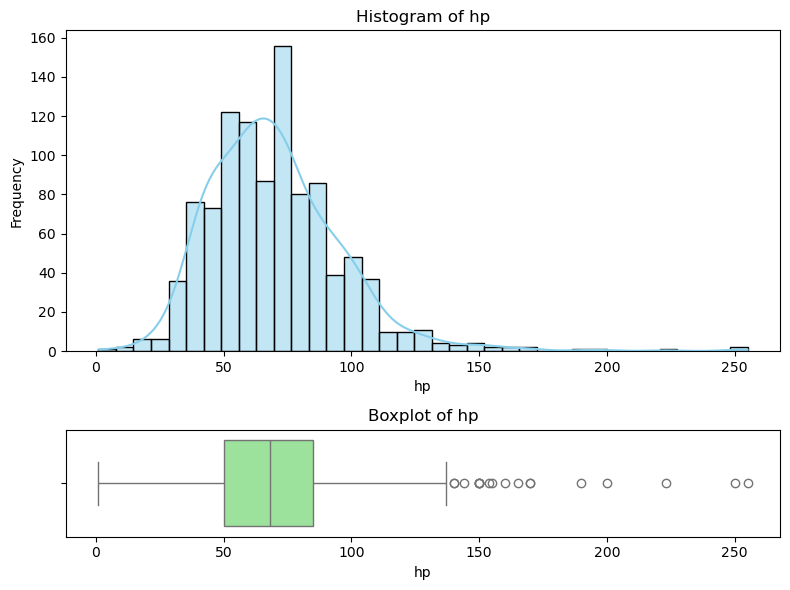

attack Hist and Box plot


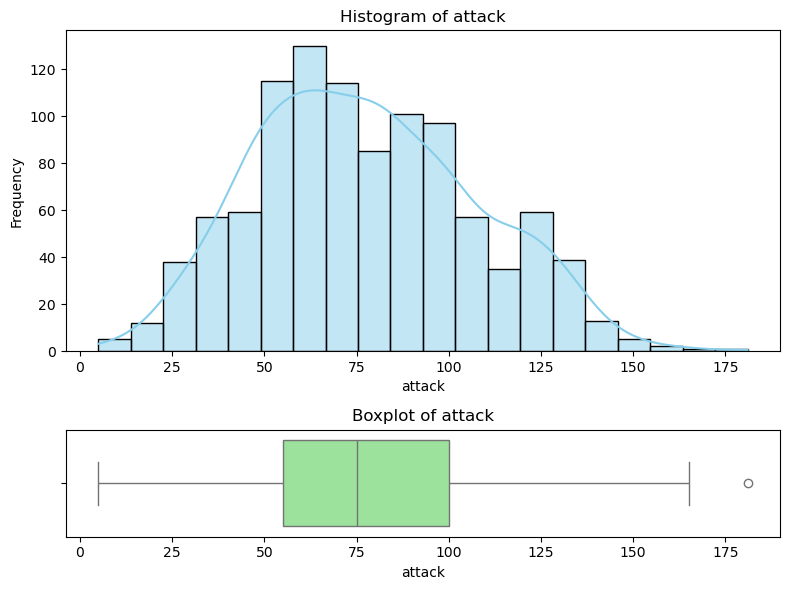

defense Hist and Box plot


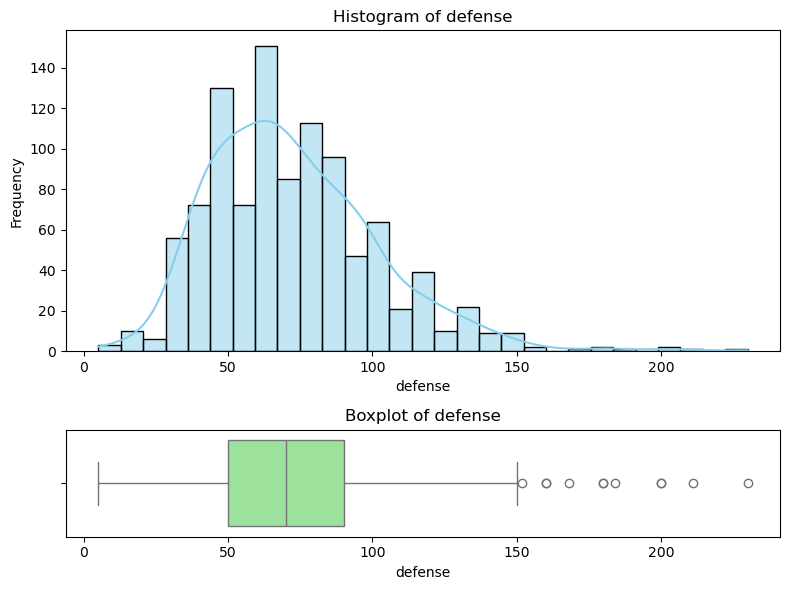

special-attack Hist and Box plot


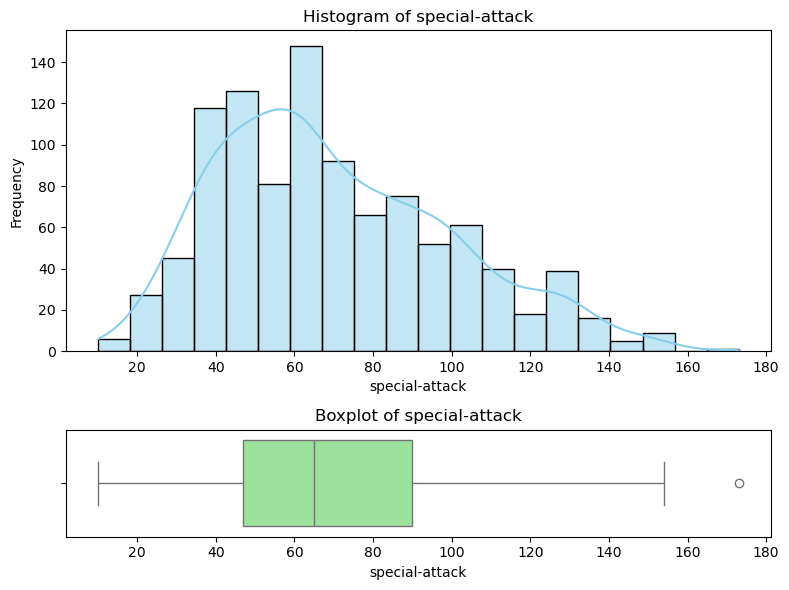

special-defense Hist and Box plot


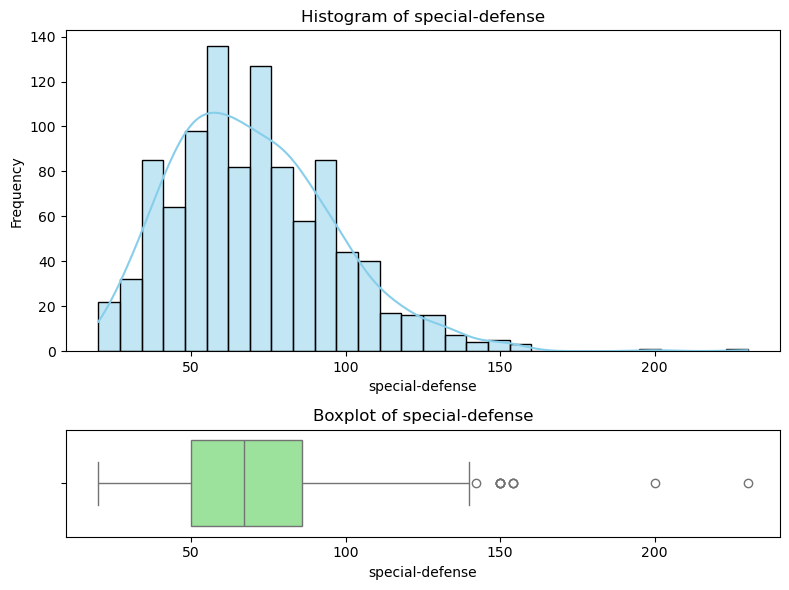

speed Hist and Box plot


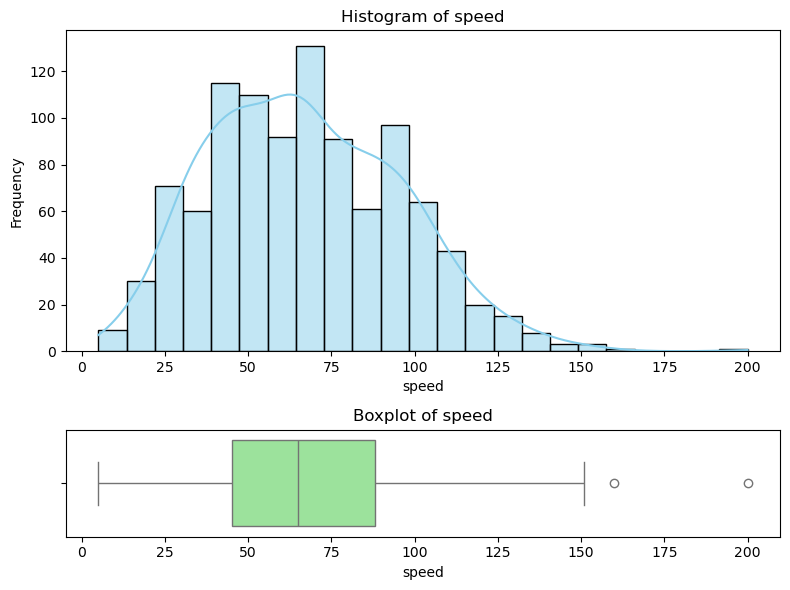

In [11]:
for col in numerical_columns:
    print(f'{col} Hist and Box plot')
    plot_hist_and_box(df,col)


In [12]:
num_nulls = df.isnull().sum()
num_nulls

id                 0
name               0
height             0
weight             0
types              0
abilities          0
hp                 0
attack             0
defense            0
special-attack     0
special-defense    0
speed              0
dtype: int64

In [14]:
# Show all duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [id, name, height, weight, types, abilities, hp, attack, defense, special-attack, special-defense, speed]
Index: []


In [15]:
df.head()

,id,name,height,weight,types,abilities,hp,attack,defense,special-attack,special-defense,speed
0,1,bulbasaur,7,69,"grass,poison","overgrow,chlorophyll",45,49,49,65,65,45
1,2,ivysaur,10,130,"grass,poison","overgrow,chlorophyll",60,62,63,80,80,60
2,3,venusaur,20,1000,"grass,poison","overgrow,chlorophyll",80,82,83,100,100,80
3,4,charmander,6,85,fire,"blaze,solar-power",39,52,43,60,50,65
4,5,charmeleon,11,190,fire,"blaze,solar-power",58,64,58,80,65,80


In [16]:
df.shape

(1025, 12)

In [18]:
df['name'].nunique()


1025

In [26]:
from collections import Counter

type_counter = Counter()

for types_str in df['types']:
    types = [t.strip() for t in types_str.split(',')]
    type_counter.update(types)

# Convert to DataFrame for easy plotting or viewing
type_counts_df = pd.DataFrame(type_counter.items(), columns=['Type', 'Count']).sort_values('Count', ascending=False)

print(type_counts_df)

        Type  Count
4      water    154
6     normal    131
0      grass    127
3     flying    109
11   psychic    102
5        bug     92
1     poison     83
2       fire     81
8     ground     75
12      rock     74
10  fighting     73
16    dragon     70
17      dark     69
7   electric     69
15     ghost     65
13     steel     65
9      fairy     64
14       ice     48


C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_63820\903592250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_counts_df, x='Type', y='Count', palette='viridis')


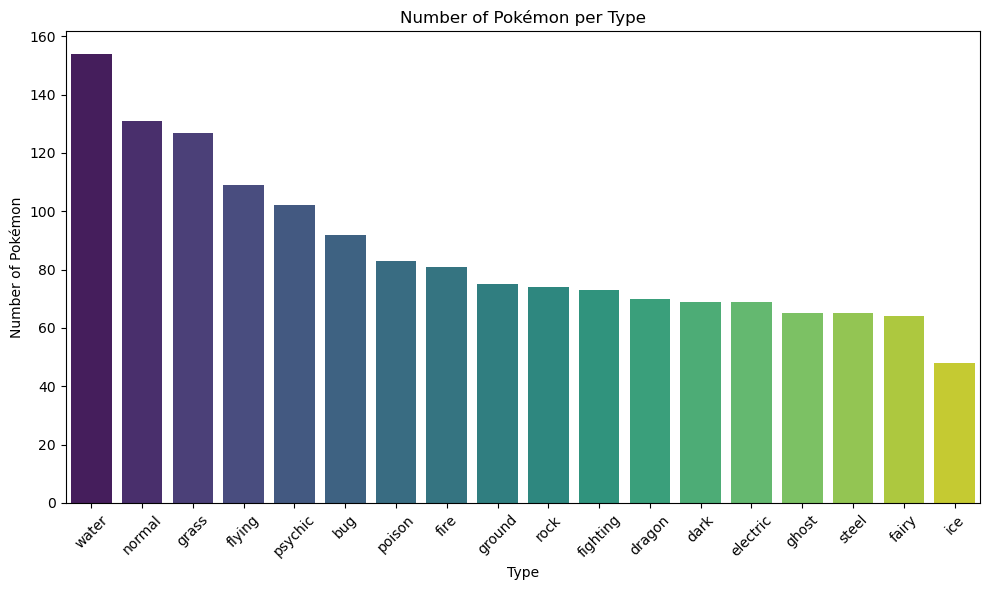

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=type_counts_df, x='Type', y='Count', palette='viridis')
plt.title('Number of Pokémon per Type')
plt.xlabel('Type')
plt.ylabel('Number of Pokémon')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
from collections import defaultdict
import pandas as pd

# Dictionary to store all speeds for each type
type_speeds = defaultdict(list)

for _, row in df.iterrows():
    speed = row['speed']
    types = [t.strip() for t in row['types'].split(',')]
    for t in types:
        type_speeds[t].append(speed)

# Calculate average speed for each type
avg_speed_per_type = {t: sum(speeds)/len(speeds) for t, speeds in type_speeds.items()}

# Convert to DataFrame for easy viewing and plotting
avg_speed_df = pd.DataFrame(list(avg_speed_per_type.items()), columns=['Type', 'Average Speed']).sort_values('Average Speed', ascending=False)

print(avg_speed_df)

        Type  Average Speed
3     flying      82.431193
7   electric      81.869565
16    dragon      78.171429
17      dark      76.782609
10  fighting      75.397260
2       fire      74.135802
11   psychic      71.598039
6     normal      68.908397
1     poison      68.469880
15     ghost      66.184615
9      fairy      65.703125
4      water      65.558442
14       ice      65.437500
13     steel      60.169231
5        bug      60.152174
0      grass      59.685039
8     ground      58.466667
12      rock      51.783784


C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_63820\466381968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_speed_df, x='Type', y='Average Speed', palette='mako')


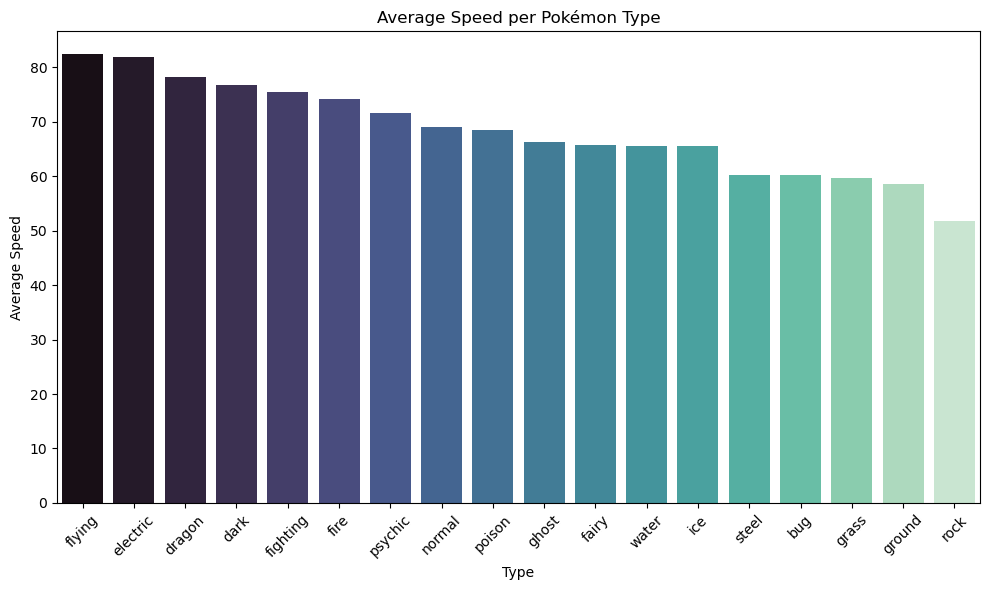

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_speed_df, x='Type', y='Average Speed', palette='mako')
plt.title('Average Speed per Pokémon Type')
plt.xlabel('Type')
plt.ylabel('Average Speed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
from collections import defaultdict
import pandas as pd

# Dictionary to store all HP values for each type
type_hp = defaultdict(list)

for _, row in df.iterrows():
    hp = row['hp']
    types = [t.strip() for t in row['types'].split(',')]
    for t in types:
        type_hp[t].append(hp)

# Calculate average HP for each type
avg_hp_per_type = {t: sum(hps)/len(hps) for t, hps in type_hp.items()}

# Convert to DataFrame for easy viewing and plotting
avg_hp_df = pd.DataFrame(list(avg_hp_per_type.items()), columns=['Type', 'Average HP']).sort_values('Average HP', ascending=False)

print(avg_hp_df)

        Type  Average HP
16    dragon   84.071429
14       ice   80.083333
10  fighting   77.753425
8     ground   77.053333
6     normal   76.557252
17      dark   76.275362
11   psychic   73.764706
13     steel   70.953846
3     flying   70.357798
2       fire   69.938272
4      water   69.597403
12      rock   68.851351
7   electric   68.681159
9      fairy   67.234375
0      grass   66.125984
1     poison   66.048193
15     ghost   65.707692
5        bug   56.576087


C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_63820\656615751.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_hp_df, x='Type', y='Average HP', palette='crest')


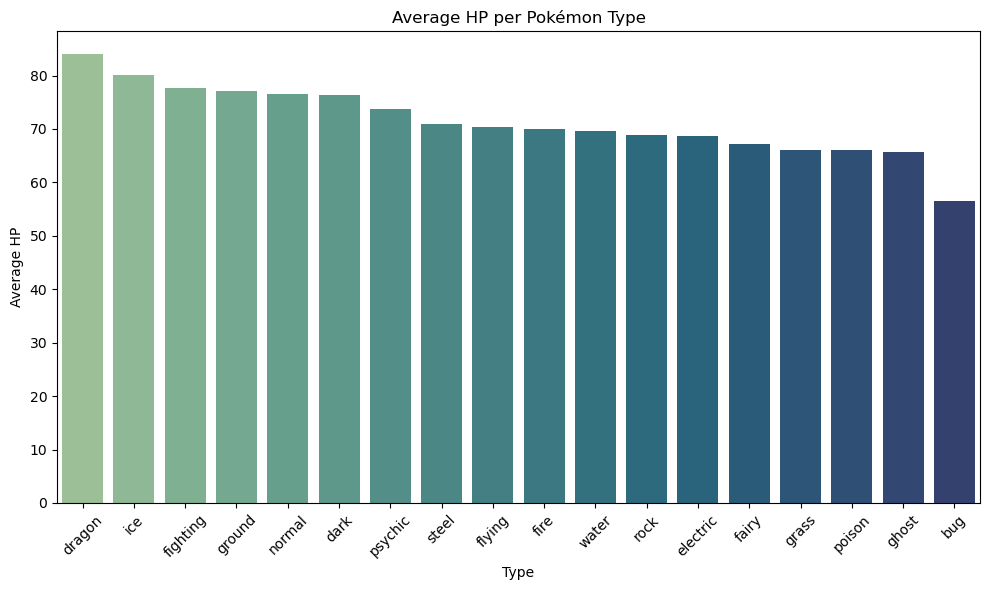

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_hp_df, x='Type', y='Average HP', palette='crest')
plt.title('Average HP per Pokémon Type')
plt.xlabel('Type')
plt.ylabel('Average HP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
from collections import defaultdict
import pandas as pd

# Dictionary to store all attack values for each type
type_attack = defaultdict(list)

for _, row in df.iterrows():
    attack = row['attack']
    types = [t.strip() for t in row['types'].split(',')]
    for t in types:
        type_attack[t].append(attack)

# Calculate average attack for each type
avg_attack_per_type = {t: sum(attacks)/len(attacks) for t, attacks in type_attack.items()}

# Convert to DataFrame for easy viewing and plotting
avg_attack_df = pd.DataFrame(list(avg_attack_per_type.items()), columns=['Type', 'Average Attack']).sort_values('Average Attack', ascending=False)

print(avg_attack_df)

        Type  Average Attack
10  fighting      104.328767
16    dragon       94.000000
17      dark       93.594203
13     steel       90.723077
8     ground       88.440000
12      rock       87.175676
14       ice       82.270833
2       fire       80.592593
15     ghost       77.400000
3     flying       76.669725
7   electric       74.884058
0      grass       74.763780
6     normal       74.007634
4      water       72.090909
1     poison       71.554217
5        bug       68.010870
11   psychic       67.294118
9      fairy       64.687500


C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_63820\1848600862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_attack_df, x='Type', y='Average Attack', palette='flare')


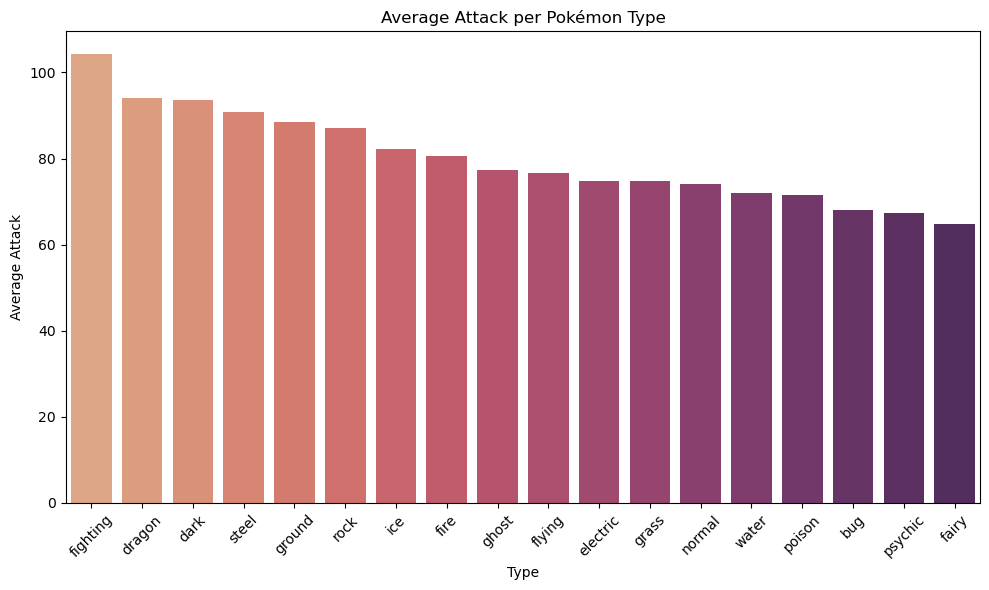

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_attack_df, x='Type', y='Average Attack', palette='flare')
plt.title('Average Attack per Pokémon Type')
plt.xlabel('Type')
plt.ylabel('Average Attack')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
from collections import defaultdict
import pandas as pd

# List of stats to include in the heatmap
stats = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']

# Dictionary to collect stat values for each type
type_stats = defaultdict(lambda: defaultdict(list))

for _, row in df.iterrows():
    types = [t.strip() for t in row['types'].split(',')]
    for t in types:
        for stat in stats:
            type_stats[t][stat].append(row[stat])

# Calculate averages
avg_stats_per_type = {
    t: {stat: sum(values)/len(values) for stat, values in stat_dict.items()}
    for t, stat_dict in type_stats.items()
}

# Convert to DataFrame for heatmap
heatmap_df = pd.DataFrame(avg_stats_per_type).T[stats]  # Types as rows, stats as columns

# print(heatmap_df)

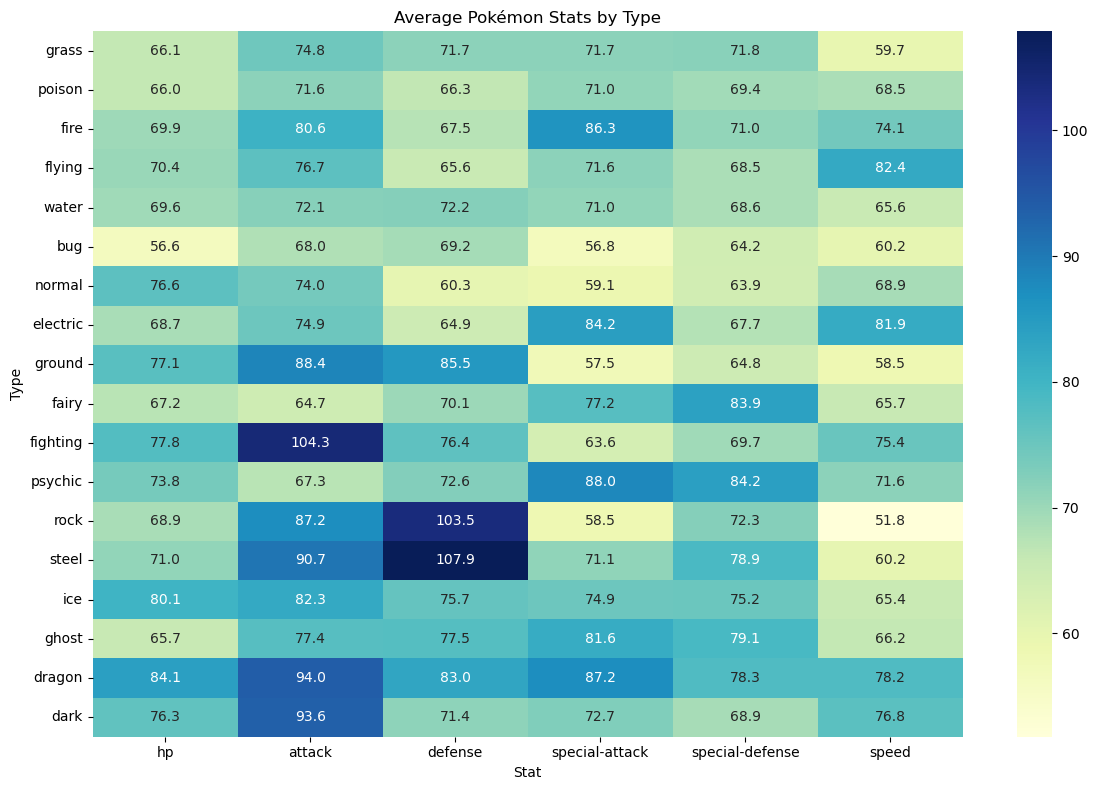

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Pokémon Stats by Type")
plt.xlabel("Stat")
plt.ylabel("Type")
plt.tight_layout()
plt.show()

In [46]:
import pandas as pd

# Select only numerical columns
numerical_df = df.select_dtypes(include='number')

# Drop the 'id' column if it exists
if 'id' in numerical_df.columns:
    numerical_df = numerical_df.drop(columns=['id'])

# Compute the correlation matrix
corr_matrix = numerical_df.corr()

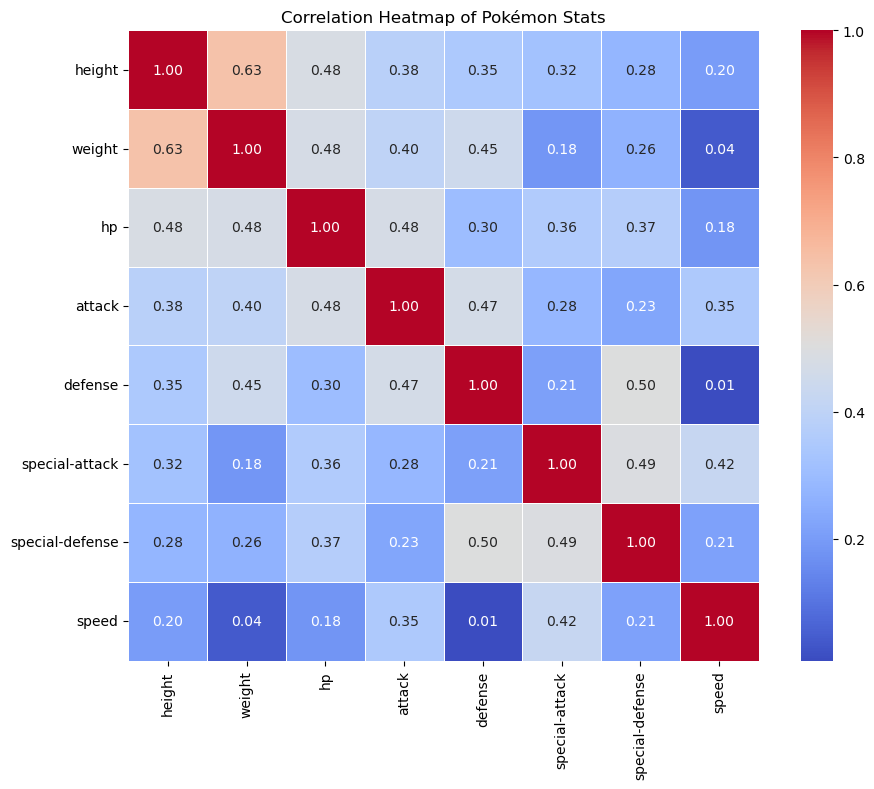

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title("Correlation Heatmap of Pokémon Stats")
plt.tight_layout()
plt.show()

In [25]:
df.head()

,id,name,height,weight,types,abilities,hp,attack,defense,special-attack,special-defense,speed
0,1,bulbasaur,7,69,"grass,poison","overgrow,chlorophyll",45,49,49,65,65,45
1,2,ivysaur,10,130,"grass,poison","overgrow,chlorophyll",60,62,63,80,80,60
2,3,venusaur,20,1000,"grass,poison","overgrow,chlorophyll",80,82,83,100,100,80
3,4,charmander,6,85,fire,"blaze,solar-power",39,52,43,60,50,65
4,5,charmeleon,11,190,fire,"blaze,solar-power",58,64,58,80,65,80


In [49]:
lst=[]
for i,j in zip(df['types'], df['name']):
    count =len(i.split(','))
    if count>1:
        lst.append(j)

print(lst) 
    

['bulbasaur', 'ivysaur', 'venusaur', 'charizard', 'butterfree', 'weedle', 'kakuna', 'beedrill', 'pidgey', 'pidgeotto', 'pidgeot', 'spearow', 'fearow', 'nidoqueen', 'nidoking', 'jigglypuff', 'wigglytuff', 'zubat', 'golbat', 'oddish', 'gloom', 'vileplume', 'paras', 'parasect', 'venonat', 'venomoth', 'poliwrath', 'bellsprout', 'weepinbell', 'victreebel', 'tentacool', 'tentacruel', 'geodude', 'graveler', 'golem', 'slowpoke', 'slowbro', 'magnemite', 'magneton', 'farfetchd', 'doduo', 'dodrio', 'dewgong', 'cloyster', 'gastly', 'haunter', 'gengar', 'onix', 'exeggcute', 'exeggutor', 'rhyhorn', 'rhydon', 'starmie', 'mr-mime', 'scyther', 'jynx', 'gyarados', 'lapras', 'omanyte', 'omastar', 'kabuto', 'kabutops', 'aerodactyl', 'articuno', 'zapdos', 'moltres', 'dragonite', 'hoothoot', 'noctowl', 'ledyba', 'ledian', 'spinarak', 'ariados', 'crobat', 'chinchou', 'lanturn', 'igglybuff', 'togetic', 'natu', 'xatu', 'marill', 'azumarill', 'hoppip', 'skiploom', 'jumpluff', 'yanma', 'wooper', 'quagsire', 'mur

In [50]:
len(lst)

526